<h1>Ансамбли моделей машинного обучения. Часть 1.</h1>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
%matplotlib inline 
sns.set(style="ticks")
data = pd.read_csv('Spotify_Music.csv', sep=",")

data.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
print(data.isnull().sum())

data_cleaned = data.dropna()

print(f"\nРазмер данных до очистки: {data.shape}")
print(f"Размер данных после очистки: {data_cleaned.shape}")

data_cleaned = data_cleaned.drop(["Unnamed: 0", "track_id", "track_name", "album_name"], axis=1)

print(f"\nУникальные значения в столбцах до очистки: {data.nunique()}")
print(f"\nУникальные значения в столбцах после очистки: {data_cleaned.nunique()}")

data = data_cleaned

data.head(5)

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Размер данных до очистки: (114000, 21)
Размер данных после очистки: (113999, 21)

Уникальные значения в столбцах до очистки: Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness         

,artists,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
data['duration_sec'] = data['duration_ms'] / 1000

q01 = data['duration_sec'].quantile(0.01)
q99 = data['duration_sec'].quantile(0.99)
data['duration_clipped'] = data['duration_sec'].clip(q01, q99)

data['duration_log'] = np.log1p(data['duration_clipped'])

data = data.drop('duration_ms', axis=1)

In [4]:
data['tempo'] = data['tempo'].fillna(data['tempo'].median())

data['tempo_clipped'] = data['tempo'].clip(60, 220)

data = data.drop('tempo', axis=1)

In [5]:
artist_counts = data['artists'].value_counts()
        
data['artist_freq'] = data['artists'].map(artist_counts)
data['artist_freq_log'] = np.log1p(data['artist_freq'])

data['artist_is_rare'] = (data['artist_freq'] < 5).astype(int)
data['artist_is_single'] = (data['artist_freq'] == 1).astype(int)

data = data.drop('artists', axis=1)

In [6]:
data['explicit'] = data['explicit'].astype(int)
le_genre = LabelEncoder()
data['track_genre_label'] = le_genre.fit_transform(data['track_genre'])
data = data.drop('track_genre', axis=1)

In [7]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")


Размер обучающей выборки: (79799, 22)
Размер тестовой выборки: (34200, 22)



Результаты на ТЕСТОВОЙ выборке:
  MSE:  223.1928
  MAE:  10.6094
  R²:   0.5500

Обучающая выборка R²: 0.9017
Разница train-test R²: 0.3518


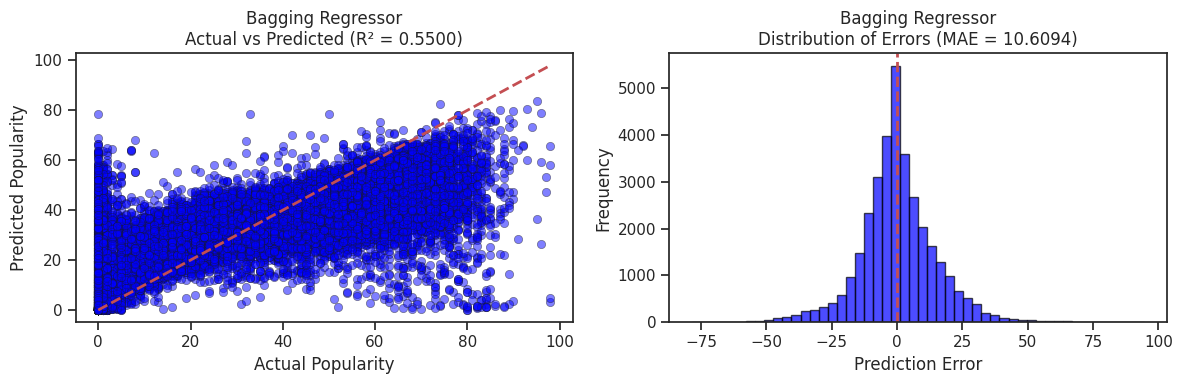

In [8]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import (
    BaggingRegressor, 
    RandomForestRegressor, 
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
import warnings
warnings.filterwarnings('ignore')

target_column = 'popularity'

X_train = train_data.drop(target_column, axis=1)
y_train = train_data[target_column]
X_test = test_data.drop(target_column, axis=1)
y_test = test_data[target_column]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. BAGGING REGRESSOR
bagging_model = BaggingRegressor(
    n_estimators=100,
    max_samples=0.9,
    max_features=0.9,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train_scaled, y_train)

y_pred_bagging = bagging_model.predict(X_test_scaled)

mse_bagging = mean_squared_error(y_test, y_pred_bagging)
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print(f"\nРезультаты на ТЕСТОВОЙ выборке:")
print(f"  MSE:  {mse_bagging:.4f}")
print(f"  MAE:  {mae_bagging:.4f}")
print(f"  R²:   {r2_bagging:.4f}")

y_train_pred_bagging = bagging_model.predict(X_train_scaled)
train_r2_bagging = r2_score(y_train, y_train_pred_bagging)
print(f"\nОбучающая выборка R²: {train_r2_bagging:.4f}")
print(f"Разница train-test R²: {train_r2_bagging - r2_bagging:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_bagging, alpha=0.5, c='blue', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Bagging Regressor\nActual vs Predicted (R² = {r2_bagging:.4f})')

errors_bagging = y_test - y_pred_bagging
axes[1].hist(errors_bagging, bins=50, edgecolor='black', color='blue', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Bagging Regressor\nDistribution of Errors (MAE = {mae_bagging:.4f})')

plt.tight_layout()
plt.show()


Результаты на ТЕСТОВОЙ выборке:
  MSE:  244.9388
  MAE:  11.3775
  R²:   0.5061

Обучающая выборка R²: 0.7836
Разница train-test R²: 0.2775

Топ-10 наиболее важных признаков:
          feature  importance
track_genre_label    0.192226
     acousticness    0.076208
     danceability    0.075057
           energy    0.066653
         loudness    0.065507
      speechiness    0.064899
          valence    0.062150
 instrumentalness    0.060464
    tempo_clipped    0.060178
         liveness    0.053879


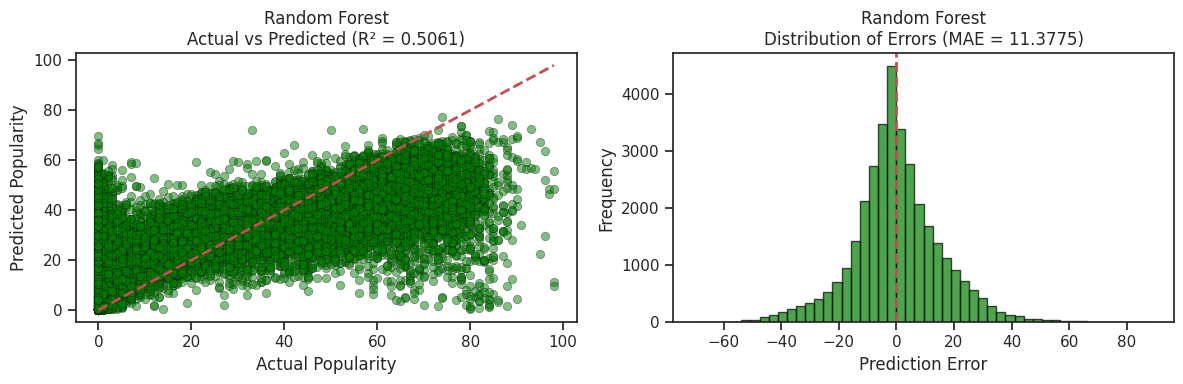

In [9]:
# 2. RANDOM FOREST
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nРезультаты на ТЕСТОВОЙ выборке:")
print(f"  MSE:  {mse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

y_train_pred_rf = rf_model.predict(X_train_scaled)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
print(f"\nОбучающая выборка R²: {train_r2_rf:.4f}")
print(f"Разница train-test R²: {train_r2_rf - r2_rf:.4f}")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-10 наиболее важных признаков:")
print(feature_importance.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_rf, alpha=0.5, c='green', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Random Forest\nActual vs Predicted (R² = {r2_rf:.4f})')

errors_rf = y_test - y_pred_rf
axes[1].hist(errors_rf, bins=50, edgecolor='black', color='green', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Random Forest\nDistribution of Errors (MAE = {mae_rf:.4f})')

plt.tight_layout()
plt.show()


Результаты на ТЕСТОВОЙ выборке:
  MSE:  466.9393
  MAE:  18.1132
  R²:   0.0585

Обучающая выборка R²: 0.0567
Разница train-test R²: -0.0018


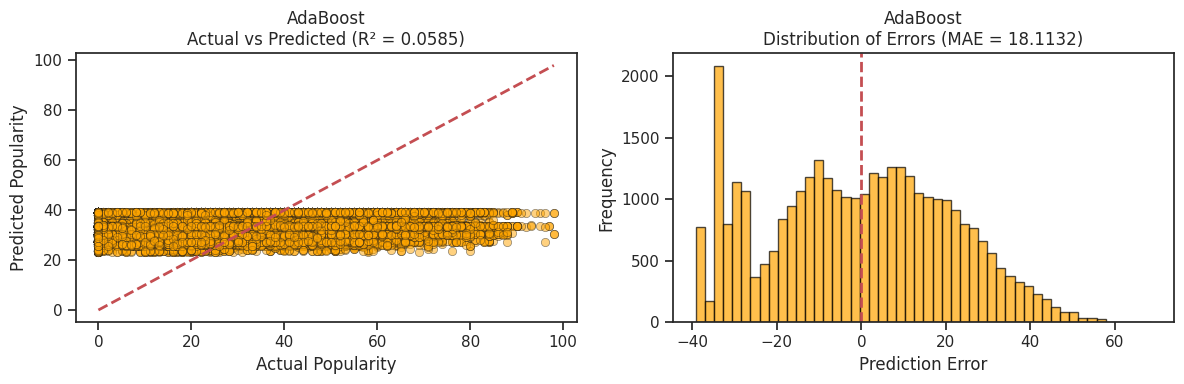

In [13]:
# 3. ADABOOST
adaboost_model = AdaBoostRegressor(
    n_estimators=50,
    learning_rate=0.05,
    random_state=42,
    loss='linear'
)

adaboost_model.fit(X_train_scaled, y_train)

y_pred_ada = adaboost_model.predict(X_test_scaled)

mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print(f"\nРезультаты на ТЕСТОВОЙ выборке:")
print(f"  MSE:  {mse_ada:.4f}")
print(f"  MAE:  {mae_ada:.4f}")
print(f"  R²:   {r2_ada:.4f}")

y_train_pred_ada = adaboost_model.predict(X_train_scaled)
train_r2_ada = r2_score(y_train, y_train_pred_ada)
print(f"\nОбучающая выборка R²: {train_r2_ada:.4f}")
print(f"Разница train-test R²: {train_r2_ada - r2_ada:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_ada, alpha=0.5, c='orange', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'AdaBoost\nActual vs Predicted (R² = {r2_ada:.4f})')

errors_ada = y_test - y_pred_ada
axes[1].hist(errors_ada, bins=50, edgecolor='black', color='orange', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'AdaBoost\nDistribution of Errors (MAE = {mae_ada:.4f})')

plt.tight_layout()
plt.show()


Результаты на ТЕСТОВОЙ выборке:
  MSE:  321.9398
  MAE:  13.7058
  R²:   0.3509

Обучающая выборка R²: 0.3798
Разница train-test R²: 0.0290

Топ-10 наиболее важных признаков (Gradient Boosting):
          feature  importance
track_genre_label    0.393091
      artist_freq    0.087632
  artist_freq_log    0.085882
     acousticness    0.061752
     danceability    0.052452
 instrumentalness    0.050411
           energy    0.040522
         loudness    0.038827
          valence    0.033404
      speechiness    0.031816


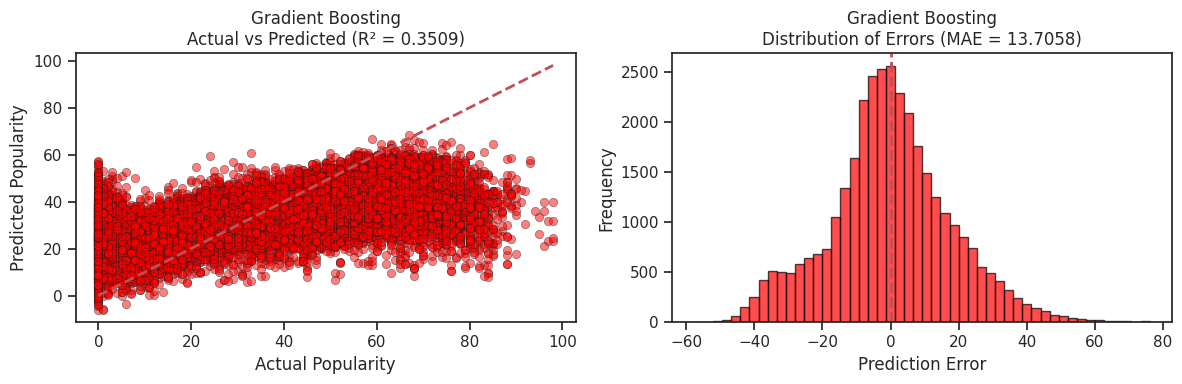

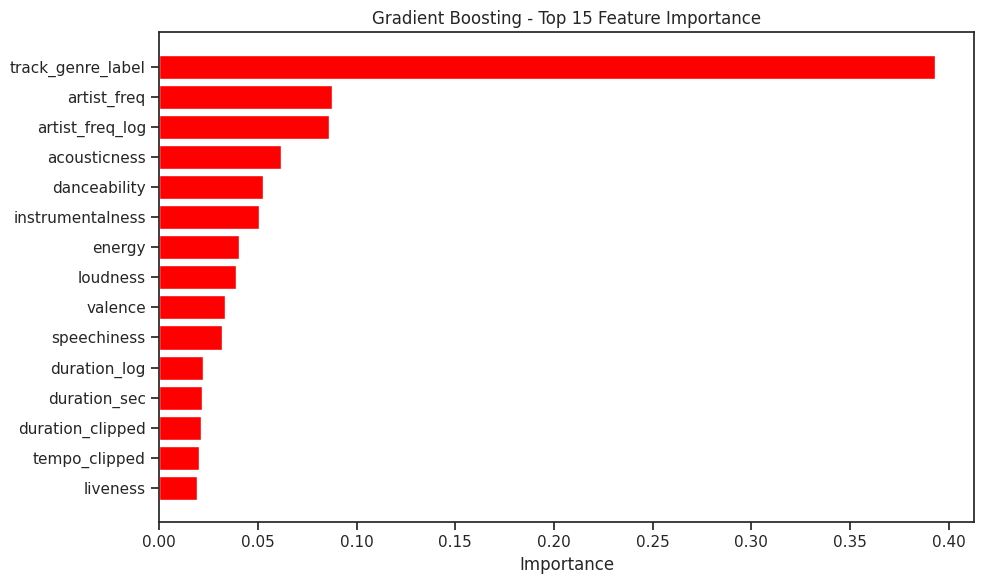

In [11]:
# 4. GRADIENT BOOSTING
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=10,
    subsample=0.8,
    max_features=0.8,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"\nРезультаты на ТЕСТОВОЙ выборке:")
print(f"  MSE:  {mse_gb:.4f}")
print(f"  MAE:  {mae_gb:.4f}")
print(f"  R²:   {r2_gb:.4f}")

y_train_pred_gb = gb_model.predict(X_train_scaled)
train_r2_gb = r2_score(y_train, y_train_pred_gb)
print(f"\nОбучающая выборка R²: {train_r2_gb:.4f}")
print(f"Разница train-test R²: {train_r2_gb - r2_gb:.4f}")

gb_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-10 наиболее важных признаков (Gradient Boosting):")
print(gb_feature_importance.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_gb, alpha=0.5, c='red', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Gradient Boosting\nActual vs Predicted (R² = {r2_gb:.4f})')

errors_gb = y_test - y_pred_gb
axes[1].hist(errors_gb, bins=50, edgecolor='black', color='red', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Gradient Boosting\nDistribution of Errors (MAE = {mae_gb:.4f})')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(gb_feature_importance.head(15)['feature'], gb_feature_importance.head(15)['importance'], color='red')
plt.xlabel('Importance')
plt.title('Gradient Boosting - Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

models = {
    'Bagging': bagging_model,
    'RandomForest': rf_model,
    'AdaBoost': adaboost_model,
    'GradientBoosting': gb_model
}

results_list = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_list.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R²': r2
    })

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('R²', ascending=False)

print(results_df.to_string(index=False))

best_model = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R²']

print(f"Лучшая модель: {best_model}")
print(f"R² = {best_r2:.4f}")
print(f"MAE = {results_df.iloc[0]['MAE']:.4f}")

           Model        MSE       MAE       R²
         Bagging 223.192800 10.609357 0.549962
    RandomForest 244.938776 11.377535 0.506114
GradientBoosting 321.939815 13.705847 0.350852
        AdaBoost 484.956989 18.393268 0.022150
Лучшая модель: Bagging
R² = 0.5500
MAE = 10.6094
